# NLP Pipeline — Social Network Analysis

```
JSON files
   ↓
Load & merge
   ↓
Text combine (title + question)
   ↓
Cleaning & Stopwords (Sastrawi + custom)
   ↓
Spell Correction (SymSpell)
   ↓
Embedding (Sentence-BERT multilingual)
   ↓
Similarity → KNN
   ↓
Graph (NetworkX)
   ↓
SNA:
  - Degree
  - Betweenness
  - Eigenvector
  - Community (Louvain)
   ↓
Time aggregation (daily)
   ↓
Trending insight + Export
```

## 0. Install Dependencies

In [33]:
import sys
#!{sys.executable} -m pip install -q openpyxl symspellpy sentence-transformers python-louvain

## 1. Import & Load Data

In [34]:
import pandas as pd
import glob
import json
import os
import re
import time
import numpy as np
from collections import Counter

# =========================
# PATH — sesuaikan dengan lokasi file JSON
# =========================
folder_path = r"C:\Users\PSIAP\Downloads\data\dataset_280426"
files = glob.glob(os.path.join(folder_path, "*.json"))

print("Total files:", len(files))

# =========================
# LOAD JSONL + FIX BOM
# =========================
data = []

for file in files:
    with open(file, "r", encoding="utf-8-sig", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if line:
                try:
                    data.append(json.loads(line))
                except Exception as e:
                    print(f"Error parsing line di {file}: {e}")

# =========================
# DATAFRAME AWAL
# =========================
df = pd.DataFrame(data)
print("Sebelum flatten:", df.shape)

# =========================
# HANDLE KOLOM 'data'
# =========================
if "data" in df.columns:
    df["data"] = df["data"].apply(lambda x: x if isinstance(x, list) else [x])
    df = df.explode("data", ignore_index=True)
    df_data = pd.json_normalize(df["data"])
    df = df.drop(columns=["data"]).join(df_data)

print("Setelah flatten:", df.shape)

# =========================
# PASTIKAN KOLOM ADA
# =========================
required_cols = [
    "postid", "handle", "question_title", "question",
    "question_date", "category", "parent1", "parent2"
]

for col in required_cols:
    if col not in df.columns:
        df[col] = None

df = df[required_cols]

# =========================
# DATE PARSING — format lengkap
# =========================
df["question_date"] = pd.to_datetime(df["question_date"], errors="coerce", format="%Y-%m-%d %H:%M:%S")
df["date"] = pd.to_datetime(df["question_date"])
df["day"]  = df["date"].dt.date

# =========================
# FILTER TANGGAL: 1 Jan 2026 s.d. 30 Apr 2026
# =========================
DATE_START = pd.Timestamp("2026-01-01")
DATE_END   = pd.Timestamp("2026-04-30 23:59:59")

before_filter = len(df)
df = df[
    (df["question_date"] >= DATE_START) &
    (df["question_date"] <= DATE_END)
].reset_index(drop=True)
after_filter = len(df)

print(f"\n📅 Filter tanggal: {DATE_START.date()} s.d. {DATE_END.date()}")
print(f"   Sebelum filter : {before_filter:,} baris")
print(f"   Setelah filter : {after_filter:,} baris")
print(f"   Terhapus       : {before_filter - after_filter:,} baris")

print("\nFinal shape:", df.shape)
print(df.head(3))

Total files: 197
Sebelum flatten: (197, 3)
Setelah flatten: (19552, 21)

📅 Filter tanggal: 2026-01-01 s.d. 2026-04-30
   Sebelum filter : 19,552 baris
   Setelah filter : 1,652 baris
   Terhapus       : 17,900 baris

Final shape: (1652, 10)
  postid        handle                                     question_title  \
0  71074           a.a  Billing Deposit sudah dibayar namun belum masu...   
1  70027           a.a  Apakah Pengajuan Surat Keterangan Tidak Dipung...   
2  74511  abed.siahaan                   KENAPA LINK MELATI SELALU ERROR?   

                                            question       question_date  \
0  Mohon Bantuan\n\nPembayaran deposit tanggal 15... 2026-01-19 04:43:22   
1  Apakah Pengajuan Surat Keterangan Tidak Dipung... 2026-01-05 02:58:47   
2  <p>Mohon dibantu apakah ada link alamat melati... 2026-04-07 01:49:01   

                                            category              parent1  \
0                                     Pemindahbukuan           Pemba

## 2. Text Cleaning

In [35]:
import html
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from bs4 import BeautifulSoup
import re
import time

# =========================
# TEXT COMBINE
# =========================
df["text"] = (
    df["question_title"].fillna("") + ". " +
    df["question"].fillna("")
)

# =========================
# STOPWORDS
# =========================
factory = StopWordRemoverFactory()
stopwords_id = set(factory.get_stop_words())

custom_stopwords = {
    "atas","bawah","mohon","terkait","tentang","untuk",
    "dengan","dan","atau","yang","di","ke","dari",
    "saya","aku","kami","kita","ini","itu","adalah",
    "pada","dalam","sebagai","agar","bisa","akan",
    "selamat","pagi","siang","sore","namun",
    "tolong","silakan","please","help","problem","issue",
    "pajak","wajib","wp","coretax","bantuannya","melati",
    "lanjut","request","case","data","masa",
    "tersebut","nomor","kasus","muncul","terima","kasih",
    "bagaimana","apakah"
}
stopwords_id = stopwords_id.union(custom_stopwords)

# =========================
# NOISE TOKENS
# =========================
noise_tokens = {
    "span","style","font","class","div","br",
    "quot","nbsp","color","family","border","box",
    "id","sans"
}

# =========================
# SLANG
# =========================
slang_dict = {
    "gk": "tidak","ga": "tidak","nggak": "tidak",
    "bgt": "banget","yg": "yang","dgn": "dengan",
    "dr": "dari","tdk": "tidak","eror": "error",
    "errorr": "error","instal": "install","installl": "install",
    "piip": "pip"
}

# =========================
# CLEAN HTML (STRONG)
# =========================
def strip_html(text):
    text = html.unescape(str(text))  # 🔥 penting (handle &lt;div&gt;)

    # hapus script & style
    text = re.sub(r"<(script|style).*?>.*?</\1>", " ", text, flags=re.DOTALL)

    try:
        soup = BeautifulSoup(text, "html.parser")
        text = soup.get_text(" ")
    except:
        pass

    # fallback kalau masih ada tag
    text = re.sub(r"<.*?>", " ", text, flags=re.DOTALL)

    return text

# =========================
# CLEANING FUNCTION
# =========================
def clean_text(text):
    text = str(text).lower()

    # ===== HTML SUPER BERSIH =====
    text = strip_html(text)

    # ===== ENTITY SISA =====
    text = re.sub(r"&(?:[a-z]+|#\d+);", " ", text)

    # ===== URL =====
    text = re.sub(r"http\S+|www\S+", " ", text)

    # ===== NON TEXT =====
    text = re.sub(r"[^a-z0-9\s]", " ", text)

    # ===== NOISE KHUSUS =====
    text = re.sub(r"\b(?=[a-z0-9]*[a-z])(?=[a-z0-9]*\d)[a-z0-9]{12,}\b", " ", text)
    text = re.sub(r"\breq\d{6,}\b", " ", text, flags=re.IGNORECASE)
    text = re.sub(r"\b\d+\b", " ", text)

    # ===== NORMALISASI =====
    text = re.sub(r"\s+", " ", text).strip()

    # ===== TOKEN =====
    words = text.split()

    # slang
    words = [slang_dict.get(w, w) for w in words]

    # remove noise HTML leftover
    words = [w for w in words if w not in noise_tokens]

    # remove stopwords
    words = [w for w in words if w not in stopwords_id]

    # remove kata pendek (opsional tapi penting)
    words = [w for w in words if len(w) > 1]

    return " ".join(words)

# =========================
# APPLY CLEANING
# =========================
t0 = time.time()
df["clean_text"] = df["text"].apply(clean_text)
print(f"Cleaning selesai: {time.time()-t0:.1f}s")

df = df[df["clean_text"].str.strip() != ""].reset_index(drop=True)

print("\n🔥 Sample hasil:")
print(df[["text", "clean_text"]].head(5).to_string())
print("\n📊 Jumlah data:", len(df))

Cleaning selesai: 1.1s

🔥 Sample hasil:
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

## 4. Export Vocabulary (untuk inspeksi stopwords tambahan)

In [36]:
all_tokens = " ".join(df["clean_text"]).split()
freq = Counter(all_tokens)

vocab_df = pd.DataFrame(freq.items(), columns=["word", "freq"])
vocab_df = vocab_df.sort_values(by="freq", ascending=False)

vocab_df.to_excel("vocab_inspection.xlsx", index=False)
print("✅ vocab_inspection.xlsx berhasil dibuat")
print("\nTop 20 kata:")
print(vocab_df.head(20).to_string(index=False))

✅ vocab_inspection.xlsx berhasil dibuat

Top 20 kata:
       word  freq
        spt  1477
       npwp   734
 permohonan   528
      tahun   516
pemeriksaan   507
        pph   477
    tahunan   446
 pembetulan   398
        kpp   349
        ppn   330
      surat   319
      error   319
         lb   304
    tanggal   303
      pasal   300
     status   283
 mengajukan   282
      nilai   280
       nama   275
       menu   263


## 5. Bigram dan Trigram
!pip install gensim

In [37]:
# =========================
# BIGRAM & TRIGRAM PIPELINE (FINAL + BRACKET FIXED)
# =========================
from gensim.models import Phrases
from gensim.models.phrases import Phraser
from collections import Counter
import re

# =========================
# TOKENISASI
# =========================
sentences = [text.split() for text in df["clean_text"]]

# =========================
# BUILD BIGRAM
# =========================
bigram = Phrases(
    sentences,
    min_count=8,
    threshold=10
)
bigram_model = Phraser(bigram)

# =========================
# BUILD TRIGRAM
# =========================
trigram = Phrases(
    bigram_model[sentences],
    min_count=5,
    threshold=10
)
trigram_model = Phraser(trigram)

# =========================
# APPLY MODEL
# =========================
sentences_bigram = [bigram_model[sent] for sent in sentences]
sentences_trigram = [trigram_model[bigram_model[sent]] for sent in sentences]

# =========================
# CLEAN N-GRAM
# =========================
def clean_ngram(words):
    words = [w for w in words if not re.match(r"^\d+$", w)]
    words = [w for w in words if len(w) > 2]

    cleaned = []
    for w in words:
        if not cleaned or cleaned[-1] != w:
            cleaned.append(w)
    return cleaned

# =========================
# 🔥 BRACKET CONVERTER (KEY FIX)
# =========================
def convert_underscore_to_bracket(words):
    result = []
    for w in words:
        if "_" in w:
            phrase = w.replace("_", " ")
            result.append(f"[PHRASE] {phrase} [/PHRASE]")
        else:
            result.append(w)
    return result

# =========================
# APPLY CLEAN + BRACKET
# =========================
sentences_bigram = [
    convert_underscore_to_bracket(clean_ngram(s))
    for s in sentences_bigram
]

sentences_trigram = [
    convert_underscore_to_bracket(clean_ngram(s))
    for s in sentences_trigram
]

# =========================
# FILTER RARE N-GRAM
# =========================
def filter_rare(texts, min_freq=5):
    counter = Counter()
    for t in texts:
        counter.update(t)

    return [[w for w in t if counter[w] >= min_freq] for t in texts]

sentences_bigram = filter_rare(sentences_bigram, min_freq=5)
sentences_trigram = filter_rare(sentences_trigram, min_freq=5)

# =========================
# REMOVE BASE WORD (SAFE FOR BRACKET)
# =========================
def remove_base_words(words):
    result = []
    for w in words:
        if "[PHRASE]" in w:
            result.append(w)
            continue

        if "_" in w:
            parts = w.split("_")
            result = [r for r in result if r not in parts]

        result.append(w)
    return result

sentences_bigram = [remove_base_words(s) for s in sentences_bigram]
sentences_trigram = [remove_base_words(s) for s in sentences_trigram]

# =========================
# FINAL REFINEMENT
# =========================
def final_refinement(words):
    result = []
    seen = set()

    for w in words:
        if re.match(r"^\d+$", w):
            continue
        if re.match(r"^[a-z]*\d{5,}$", w):
            continue

        if w not in seen:
            result.append(w)
            seen.add(w)

    return result

# =========================
# DOMAIN CLEAN
# =========================
generic_words = {
    "cara","baca","per","kolomnya","sangat","membantu",
    "cek","tsb","kok","terimakasih","ditanya","kesulitan",
    "memahami","tiap","bila","mengaku","hasil","klik",
    "bantuan","arahannya","tahun","bulan"
}

def final_polish(words):
    words = [w for w in words if w not in generic_words]

    seen = set()
    result = []
    for w in words:
        if w not in seen:
            result.append(w)
            seen.add(w)

    return result

# =========================
# FINAL OUTPUT
# =========================
sentences_final = [
    final_polish(final_refinement(bi + tri))
    for bi, tri in zip(sentences_bigram, sentences_trigram)
]

df["final_text"] = [" ".join(s) for s in sentences_final]

df["bigram_text"] = [" ".join(s) for s in sentences_bigram]
df["trigram_text"] = [" ".join(s) for s in sentences_trigram]

# =========================
# RESULT
# =========================
print(df[["clean_text","bigram_text","trigram_text","final_text"]].head(5).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 clean_text                                                                                                                                                                                                                                                                                                                                                                             

## 6. Embedding (Sentence-BERT Multilingual)

Model `paraphrase-multilingual-MiniLM-L12-v2` dipilih karena mendukung Bahasa Indonesia
dan campuran Indo-Inggris, lebih akurat dari `all-MiniLM-L6-v2` yang hanya Inggris.
Embedding di-cache ke disk agar tidak perlu dihitung ulang setiap run.

In [38]:
import os
import time
import numpy as np
from sentence_transformers import SentenceTransformer

EMB_PATH = "embeddings.npy"

# =========================
# TEXT SOURCE (SUDAH FINAL PIPELINE)
# =========================
texts = df["final_text"].tolist()

# =========================
# CACHE CHECK
# =========================
if os.path.exists(EMB_PATH):
    embeddings = np.load(EMB_PATH)
    print(f"✅ Embedding dimuat dari cache: {EMB_PATH}")

    # validasi ukuran
    if embeddings.shape[0] != len(texts):
        print("⚠️ Ukuran cache tidak cocok dengan data, menghitung ulang...")
        os.remove(EMB_PATH)
        embeddings = None
else:
    embeddings = None

# =========================
# MODEL LOAD (MULTILINGUAL + BILINGUAL SAFE)
# =========================
if embeddings is None:

    model = SentenceTransformer(
        'paraphrase-multilingual-MiniLM-L12-v2',
        device='cpu'  # ganti ke 'cuda' jika ada GPU
    )

    t0 = time.time()

    embeddings = model.encode(
        texts,
        batch_size=64,
        show_progress_bar=True,
        convert_to_numpy=True,
        normalize_embeddings=True  # 🔥 penting untuk similarity
    )

    print(f"Embedding selesai: {time.time()-t0:.1f}s")

    np.save(EMB_PATH, embeddings)
    print(f"✅ Embedding disimpan ke {EMB_PATH}")

# =========================
# INFO OUTPUT
# =========================
print("Jumlah data   :", len(texts))
print("Shape embedding:", embeddings.shape)

✅ Embedding dimuat dari cache: embeddings.npy
Jumlah data   : 1652
Shape embedding: (1652, 384)


In [39]:
##Evaluasi Hasil##
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sentence_transformers import SentenceTransformer

# =========================
# LOAD MODEL (FIX UTAMA)
# =========================
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# =========================
# LOAD DATA
# =========================
emb = embeddings
texts = df["final_text"].tolist()

# =========================
# 1. COSINE SIMILARITY TEST
# =========================
def cosine_test(i=0, j=1):
    sim = cosine_similarity([emb[i]], [emb[j]])[0][0]

    print("🔹 Cosine Similarity Test")
    print("Text A:", texts[i][:120])
    print("Text B:", texts[j][:120])
    print("Similarity:", round(sim, 4))
    print()

cosine_test(0, 1)

# =========================
# 2. SEMANTIC RETRIEVAL TEST
# =========================
def semantic_search(query, top_k=5):
    q_emb = model.encode([query], normalize_embeddings=True)
    sims = cosine_similarity(q_emb, emb)[0]

    top_idx = sims.argsort()[-top_k:][::-1]

    print("🔹 Semantic Retrieval Test")
    print("Query:", query)
    print("-" * 60)

    for i in top_idx:
        print(round(sims[i], 4), "|", texts[i][:120])

    print()

semantic_search("gagal login error sistem", top_k=5)

# =========================
# 3. CLUSTERING + SILHOUETTE SCORE (FIXED)
# =========================
print("🔹 Clustering Evaluation")

k = 10

kmeans = KMeans(
    n_clusters=k,
    random_state=42,
    n_init="auto"
)

labels = kmeans.fit_predict(emb)

# silhouette (lebih fair jika >1 cluster valid)
if len(set(labels)) > 1:
    score = silhouette_score(emb, labels)
    print("Silhouette Score:", round(score, 4))

    if score > 0.5:
        print("✅ Clustering sangat baik")
    elif score > 0.25:
        print("⚠️ Clustering cukup")
    else:
        print("❌ Clustering kurang baik")
else:
    print("❌ Tidak cukup variasi cluster")

print()

# =========================
# 4. QUERY BENCHMARK
# =========================
benchmark_queries = [
    "gagal login",
    "error sistem",
    "tidak bisa akses",
    "cara penggunaan aplikasi",
    "bug aplikasi"
]

print("🔹 Benchmark Query Test")

for q in benchmark_queries:
    q_emb = model.encode([q], normalize_embeddings=True)
    sims = cosine_similarity(q_emb, emb)[0]

    top_idx = sims.argmax()

    print("\nQuery:", q)
    print("Top match similarity:", round(sims[top_idx], 4))
    print("Match text:", texts[top_idx][:120])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

🔹 Cosine Similarity Test
Text A: billing deposit dibayar buku pembayaran [PHRASE] tanggal januari [/PHRASE] npwp ntpn [PHRASE] kode billing [/PHRASE]
Text B: pengajuan [PHRASE] surat keterangan [/PHRASE] dipungut sktd menu layanan perpajakan akun legacy djponline
Similarity: 0.5197

🔹 Semantic Retrieval Test
Query: gagal login error sistem
------------------------------------------------------------
0.6819 | login petugas intranet error solusinya
0.6621 | kesalahan membaca sikka aplikasi sehubungan error login nama pegawai cuti
0.6556 | gagal login sandi informasi mengalami akun [PHRASE] keterangan error [/PHRASE] valid diinput info jumat solusi
0.6184 | gagal login ganti password tampilan kendalanya npwp pengajuan ubah sandi merubah
0.5593 | kendala login ereg izin notifikasi password salah diinput sdh sesuai sikka

🔹 Clustering Evaluation
Silhouette Score: 0.0348
❌ Clustering kurang baik

🔹 Benchmark Query Test

Query: gagal login
Top match similarity: 0.6865
Match text: kesalahan me

✅ Cleaning selesai


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ FAISS ready | data: 1652

🔹 QUERY: gagal login error sistem
------------------------------------------------------------
0.7583 | gagal login sandi informasi mengalami akun keterangan error valid diinput info jumat solusi
0.6819 | login petugas intranet error solusinya
0.6621 | kesalahan membaca sikka aplikasi sehubungan error login nama pegawai cuti

🔹 WORDCLOUD (SEARCH RESULT)


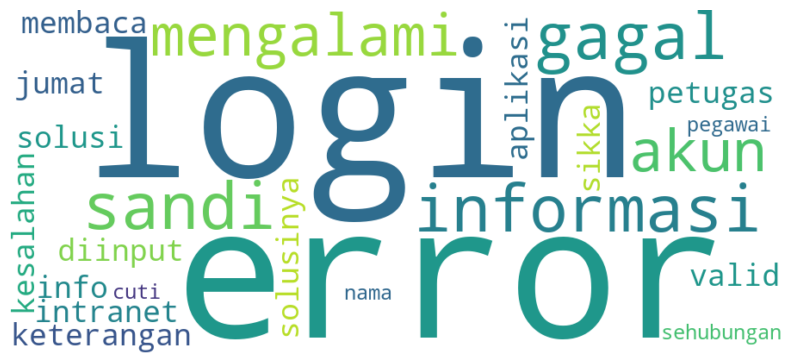


🔹 WORDCLOUD (GLOBAL)


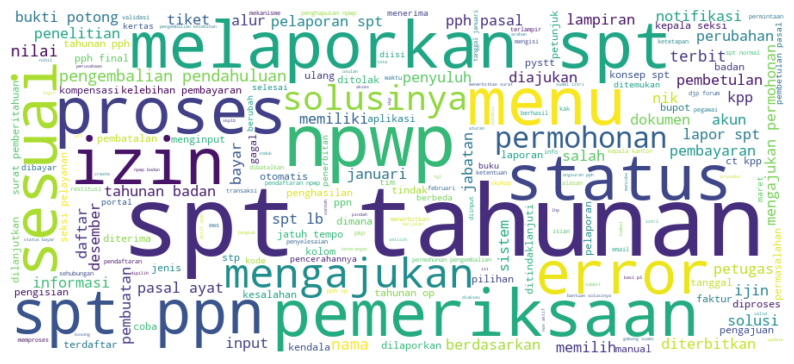


🔹 GROUP SUMMARY
Group 0 size: 1
- adakah tutorial pencabutan pkp permohonan pengukuhan pkp
Group 1 size: 2
- pendaftaran npwp pemberitahuan terdaftar ditemukan npwpnya sistem ahu ahu ah nama diproses npwp peru
- perusahaan memiliki npwp abadi jaya keputusan pengesahan ahu ah tanggal februari error berdasarkan n
Group 2 size: 1
- bupot a2 get bupot penghasilan juta terbit pns diterbitkan kendala pemberi ditarik direkam manual di
Group 3 size: 1
- kepala kantor melanjutkan cabut blokir pbk rekening penyitaan blokir harta membayar utang biaya pena
Group 4 size: 1
- lapor ppn pkp konsep spt spt ppn pedoman penghitungan pengkreditan januari dikukuhkan agustus melapo


In [40]:
import numpy as np
import faiss
import re
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# =========================
# 1. CLEANING FUNCTION (FIX UTAMA)
# =========================
def clean_text(text):
    text = str(text)

    # hapus tag PHRASE
    text = re.sub(r"\[/?PHRASE\]", "", text)

    # hapus karakter aneh / multiple space
    text = re.sub(r"\s+", " ", text)

    # hapus angka panjang (noise ID)
    text = re.sub(r"\b\d{4,}\b", "", text)

    return text.strip()

# =========================
# 2. APPLY CLEANING
# =========================
df["clean_final"] = df["final_text"].apply(clean_text)
texts = df["clean_final"].tolist()

print("✅ Cleaning selesai")

# =========================
# 3. LOAD MODEL
# =========================
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# =========================
# 4. EMBEDDING (PASTIKAN CLEAN DATA)
# =========================
embeddings = model.encode(texts, normalize_embeddings=True)
emb = np.array(embeddings).astype(np.float32)

# =========================
# 5. BUILD FAISS INDEX
# =========================
dim = emb.shape[1]
index = faiss.IndexFlatIP(dim)
index.add(emb)

print("✅ FAISS ready | data:", index.ntotal)

# =========================
# 6. SEARCH FUNCTION (WITH THRESHOLD)
# =========================
def search(query, top_k=5, threshold=0.65):
    q_emb = model.encode([query], normalize_embeddings=True)
    q_emb = np.array(q_emb).astype(np.float32).reshape(1, -1)

    scores, idx = index.search(q_emb, top_k)

    print("\n🔹 QUERY:", query)
    print("-" * 60)

    results = []

    for score, i in zip(scores[0], idx[0]):
        score = float(score)

        if score >= threshold:
            print(round(score, 4), "|", texts[i][:120])
            results.append(texts[i])

    return results

# =========================
# 7. WORDCLOUD FUNCTION
# =========================
def wordcloud(text_list):
    text = " ".join(text_list)

    wc = WordCloud(
        width=900,
        height=400,
        background_color="white"
    ).generate(text)

    plt.figure(figsize=(10,5))
    plt.imshow(wc, interpolation="bilinear")
    plt.axis("off")
    plt.show()

# =========================
# 8. SIMPLE GROUPING (MVP VERSION)
# =========================
def simple_grouping(sample_size=80, threshold=0.75):
    groups = []
    used = set()

    sample_idx = np.random.choice(len(texts), sample_size, replace=False)

    for i in sample_idx:
        if i in used:
            continue

        group = [i]
        used.add(i)

        for j in sample_idx:
            if j not in used:
                sim = np.dot(emb[i], emb[j])
                if sim >= threshold:
                    group.append(j)
                    used.add(j)

        groups.append(group)

    return groups

# =========================
# 9. RUN DEMO
# =========================

# SEARCH TEST
results = search("gagal login error sistem", top_k=10, threshold=0.65)

# WORDCLOUD dari hasil search
if results:
    print("\n🔹 WORDCLOUD (SEARCH RESULT)")
    wordcloud(results)

# WORDCLOUD global
print("\n🔹 WORDCLOUD (GLOBAL)")
wordcloud(texts)

# GROUPING
groups = simple_grouping()

print("\n🔹 GROUP SUMMARY")
for i, g in enumerate(groups[:5]):
    print(f"Group {i} size:", len(g))
    for idx in g[:3]:
        print("-", texts[idx][:100])

In [41]:
import faiss
import numpy as np
from sentence_transformers import SentenceTransformer

# =========================
# LOAD MODEL (AMAN)
# =========================
model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

# =========================
# LOAD DATA
# =========================
texts = df["final_text"].tolist()

# =========================
# BUILD EMBEDDINGS (PASTIKAN FLOAT32)
# =========================
emb = embeddings.astype(np.float32)

# =========================
# NORMALIZE EMBEDDINGS
# =========================
emb_norm = emb / np.linalg.norm(emb, axis=1, keepdims=True)
emb_norm = emb_norm.astype(np.float32)

dim = emb_norm.shape[1]

# =========================
# BUILD FAISS INDEX
# =========================
index = faiss.IndexFlatIP(dim)
index.add(emb_norm)

print("✅ FAISS index siap")
print("Jumlah data:", index.ntotal)
print("Dimensi:", dim)

# =========================
# SEARCH FUNCTION
# =========================
def search_faiss(query, top_k=5):
    q_emb = model.encode([query], normalize_embeddings=True)
    q_emb = np.array(q_emb).astype(np.float32).reshape(1, -1)

    scores, idx = index.search(q_emb, top_k)

    print("\n🔹 FAISS SEARCH RESULT")
    print("Query:", query)
    print("-" * 60)

    for score, i in zip(scores[0], idx[0]):
        print(round(float(score), 4), "|", texts[i][:120])

# =========================
# AUTO TEST (INI YANG SEBELUMNYA KAMU LEWATKAN)
# =========================
search_faiss("gagal login error sistem", 5)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

✅ FAISS index siap
Jumlah data: 1652
Dimensi: 384

🔹 FAISS SEARCH RESULT
Query: gagal login error sistem
------------------------------------------------------------
0.7583 | gagal login sandi informasi mengalami akun [PHRASE] keterangan error [/PHRASE] valid diinput info jumat solusi
0.6819 | login petugas intranet error solusinya
0.6621 | kesalahan membaca sikka aplikasi sehubungan error login nama pegawai cuti
0.6288 | reset mfa akun [PHRASE] aktivasi akun [/PHRASE] login password permintaan kode petugas coba ulang lupa sandi pilihan mem
0.6184 | gagal login ganti password tampilan kendalanya npwp pengajuan ubah sandi merubah


In [42]:
!pip install plotly

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [43]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================
# 1. CLEANING FUNCTION (FIX UTAMA)
# =========================
def clean_text(text):
    text = str(text)

    # hapus tag PHRASE
    text = re.sub(r"\[/?PHRASE\]", "", text)

    # hapus karakter aneh / multiple space
    text = re.sub(r"\s+", " ", text)

    # hapus angka panjang (noise ID)
    text = re.sub(r"\b\d{4,}\b", "", text)

    return text.strip()

# =========================
# 2. APPLY CLEANING
# =========================
df["clean_final"] = df["final_text"].apply(clean_text)
texts = df["clean_final"].tolist()

print("✅ Cleaning selesai")

# =========================
# 0. FIX PLOTLY RENDERER (WAJIB BIAR GAMBAR MUNCUL)
# =========================
pio.renderers.default = "browser"  # bisa juga "notebook_connected"

# =========================
# 1. DATA LIMIT (biar stabil & cepat)
# =========================
sample_texts = texts[:2000]
sample_emb = emb[:2000]

# =========================
# 2. SIMPLE CLUSTERING
# =========================
def simple_cluster(texts, embeddings, threshold=0.70):
    clusters = []
    used = set()

    for i in range(len(texts)):
        if i in used:
            continue

        group = [i]
        used.add(i)

        for j in range(len(texts)):
            if j not in used:
                sim = np.dot(embeddings[i], embeddings[j])
                if sim >= threshold:
                    group.append(j)
                    used.add(j)

        clusters.append(group)

    return clusters

clusters = simple_cluster(sample_texts, sample_emb, threshold=0.70)

# filter noise cluster
clusters = [c for c in clusters if len(c) > 2]

# ambil TOP cluster saja
clusters = sorted(clusters, key=len, reverse=True)[:15]

print("Clusters used:", len(clusters))

# =========================
# 3. TF-IDF MODEL (untuk label lebih meaningful)
# =========================
vectorizer = TfidfVectorizer(max_features=1000)
vectorizer.fit(sample_texts)

feature_names = np.array(vectorizer.get_feature_names_out())

def get_cluster_label(texts_cluster):
    tfidf = vectorizer.transform(texts_cluster)
    mean_scores = tfidf.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-1]
    return feature_names[top_idx]

# =========================
# 4. BUILD SANKEY STRUCTURE
# =========================
labels = []
label_map = {}

source = []
target = []
value = []

for i, cluster in enumerate(clusters):

    cluster_texts = [sample_texts[idx] for idx in cluster]

    # 🔥 semantic label (FIX UTAMA)
    cluster_label = get_cluster_label(cluster_texts)

    if cluster_label not in label_map:
        label_map[cluster_label] = len(labels)
        labels.append(cluster_label)

    cluster_id = label_map[cluster_label]

    # ambil beberapa contoh text
    for idx in cluster[:4]:

        text_label = sample_texts[idx][:40]

        if text_label not in label_map:
            label_map[text_label] = len(labels)
            labels.append(text_label)

        text_id = label_map[text_label]

        source.append(cluster_id)
        target.append(text_id)
        value.append(1)

# =========================
# 5. VALIDASI (WAJIB)
# =========================
print("Labels:", len(labels))
print("Links:", len(source))

assert len(source) == len(target), "Mismatch source-target!"

# =========================
# 6. SANKEY PLOT
# =========================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=15,
        thickness=18
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title="Sankey MVP (Semantic Topic Flow)",
    font_size=11
)

# =========================
# 7. FORCE DISPLAY (ANTI ERROR RENDER)
# =========================
pio.show(fig)

✅ Cleaning selesai
Clusters used: 15
Labels: 68
Links: 60


In [44]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.feature_extraction.text import TfidfVectorizer

pio.renderers.default = "browser"

# =========================
# DATA
# =========================
sample_texts = texts[:2000]
sample_emb = emb[:2000]

# =========================
# CLUSTERING
# =========================
def simple_cluster(texts, embeddings, threshold=0.70):
    clusters = []
    used = set()

    for i in range(len(texts)):
        if i in used:
            continue

        group = [i]
        used.add(i)

        for j in range(len(texts)):
            if j not in used:
                sim = np.dot(embeddings[i], embeddings[j])
                if sim >= threshold:
                    group.append(j)
                    used.add(j)

        clusters.append(group)

    return clusters

clusters = simple_cluster(sample_texts, sample_emb, threshold=0.70)
clusters = [c for c in clusters if len(c) > 2][:15]

print("Clusters:", len(clusters))

# =========================
# TF-IDF FOR MEDIATOR (KEYWORDS)
# =========================
vectorizer = TfidfVectorizer(max_features=1000)
vectorizer.fit(sample_texts)
feature_names = np.array(vectorizer.get_feature_names_out())

def get_keywords(texts_cluster, top_n=2):
    tfidf = vectorizer.transform(texts_cluster)
    mean_scores = tfidf.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-top_n:][::-1]
    return feature_names[top_idx]

# =========================
# BUILD SANKEY (3 LAYERS)
# =========================
labels = []
label_map = {}

source = []
target = []
value = []

for i, cluster in enumerate(clusters):

    cluster_texts = [sample_texts[idx] for idx in cluster]

    # =========================
    # LAYER 1: CLUSTER
    # =========================
    cluster_name = f"Cluster_{i}"

    if cluster_name not in label_map:
        label_map[cluster_name] = len(labels)
        labels.append(cluster_name)

    cluster_id = label_map[cluster_name]

    # =========================
    # LAYER 2: MEDIATOR (KEYWORDS)
    # =========================
    keywords = get_keywords(cluster_texts, top_n=2)

    for kw in keywords:

        if kw not in label_map:
            label_map[kw] = len(labels)
            labels.append(kw)

        kw_id = label_map[kw]

        # cluster → mediator
        source.append(cluster_id)
        target.append(kw_id)
        value.append(len(cluster))

        # =========================
        # LAYER 3: TEXT
        # =========================
        for idx in cluster[:3]:

            text_label = sample_texts[idx][:40]

            if text_label not in label_map:
                label_map[text_label] = len(labels)
                labels.append(text_label)

            text_id = label_map[text_label]

            # mediator → text
            source.append(kw_id)
            target.append(text_id)
            value.append(1)

# =========================
# VALIDATION
# =========================
print("Labels:", len(labels))
print("Links:", len(source))

assert len(source) == len(target)

# =========================
# PLOT
# =========================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=15,
        thickness=18
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title="Sankey 3-Layer (Cluster → Mediator → Text)",
    font_size=10
)

pio.show(fig)

Clusters: 15
Labels: 84
Links: 120


In [45]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================
# 0. PLOTLY RENDER FIX
# =========================
pio.renderers.default = "browser"

# =========================
# 1. DATA LIMIT (stabil & cepat)
# =========================
sample_texts = texts[:2000]
sample_emb = emb[:2000]

# =========================
# 2. CLUSTERING (simple semantic grouping)
# =========================
def simple_cluster(texts, embeddings, threshold=0.70):
    clusters = []
    used = set()

    for i in range(len(texts)):
        if i in used:
            continue

        group = [i]
        used.add(i)

        for j in range(len(texts)):
            if j not in used:
                sim = np.dot(embeddings[i], embeddings[j])
                if sim >= threshold:
                    group.append(j)
                    used.add(j)

        clusters.append(group)

    return clusters

clusters = simple_cluster(sample_texts, sample_emb, threshold=0.70)

# filter noise
clusters = [c for c in clusters if len(c) > 2]

# ambil TOP cluster biar stabil
clusters = sorted(clusters, key=len, reverse=True)[:15]

print("Clusters used:", len(clusters))

# =========================
# 3. TF-IDF MODEL (semantic grounding)
# =========================
vectorizer = TfidfVectorizer(max_features=1000)
vectorizer.fit(sample_texts)

feature_names = np.array(vectorizer.get_feature_names_out())

def get_cluster_label(cluster_texts):
    tfidf = vectorizer.transform(cluster_texts)
    mean_scores = tfidf.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-1]
    return feature_names[top_idx]

def get_mediator_keywords(cluster_texts, top_n=2):
    tfidf = vectorizer.transform(cluster_texts)
    mean_scores = tfidf.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-top_n:][::-1]
    return feature_names[top_idx]

# =========================
# 4. BUILD SANKEY (3 LAYERS CLEAN)
# =========================
labels = []
label_map = {}

source = []
target = []
value = []

for cluster in clusters:

    cluster_texts = [sample_texts[i] for i in cluster]

    # =========================
    # LAYER 1: SEMANTIC TOPIC (FIX UTAMA)
    # =========================
    topic_label = get_cluster_label(cluster_texts)

    if topic_label not in label_map:
        label_map[topic_label] = len(labels)
        labels.append(topic_label)

    topic_id = label_map[topic_label]

    # =========================
    # LAYER 2: MEDIATOR (KEYWORDS)
    # =========================
    keywords = get_mediator_keywords(cluster_texts, top_n=2)

    for kw in keywords:

        if kw not in label_map:
            label_map[kw] = len(labels)
            labels.append(kw)

        kw_id = label_map[kw]

        # topic → mediator
        source.append(topic_id)
        target.append(kw_id)
        value.append(len(cluster))

        # =========================
        # LAYER 3: TEXT
        # =========================
        for idx in cluster[:3]:

            text_label = sample_texts[idx][:40]

            if text_label not in label_map:
                label_map[text_label] = len(labels)
                labels.append(text_label)

            text_id = label_map[text_label]

            # mediator → text
            source.append(kw_id)
            target.append(text_id)
            value.append(1)

# =========================
# 5. VALIDATION
# =========================
print("Labels:", len(labels))
print("Links:", len(source))

assert len(source) == len(target), "Mismatch source-target!"

# =========================
# 6. SANKEY PLOT
# =========================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=15,
        thickness=18
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title="Sankey MVP (Semantic Topic → Keyword → Text)",
    font_size=10
)

# =========================
# 7. SHOW
# =========================
pio.show(fig)

Clusters used: 15
Labels: 63
Links: 120


In [46]:
import numpy as np
import plotly.graph_objects as go
import plotly.io as pio
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================
# 0. RENDER FIX
# =========================
pio.renderers.default = "browser"

# =========================
# 1. DATA LIMIT
# =========================
sample_texts = texts[:2000]
sample_emb = emb[:2000]

# =========================
# 2. CLUSTERING
# =========================
def simple_cluster(texts, embeddings, threshold=0.70):
    clusters = []
    used = set()

    for i in range(len(texts)):
        if i in used:
            continue

        group = [i]
        used.add(i)

        for j in range(len(texts)):
            if j not in used:
                sim = np.dot(embeddings[i], embeddings[j])
                if sim >= threshold:
                    group.append(j)
                    used.add(j)

        clusters.append(group)

    return clusters

clusters = simple_cluster(sample_texts, sample_emb, threshold=0.70)
clusters = [c for c in clusters if len(c) > 2]
clusters = sorted(clusters, key=len, reverse=True)[:15]

print("Clusters used:", len(clusters))

# =========================
# 3. TF-IDF MODEL
# =========================
vectorizer = TfidfVectorizer(max_features=1000)
vectorizer.fit(sample_texts)

feature_names = np.array(vectorizer.get_feature_names_out())

def get_topic_label(texts_cluster):
    tfidf = vectorizer.transform(texts_cluster)
    mean_scores = tfidf.mean(axis=0).A1
    return feature_names[mean_scores.argmax()]

def get_keywords(texts_cluster, top_n=2):
    tfidf = vectorizer.transform(texts_cluster)
    mean_scores = tfidf.mean(axis=0).A1
    top_idx = mean_scores.argsort()[-top_n:][::-1]
    return feature_names[top_idx]

# =========================
# 4. SANKEY STRUCTURE
# =========================
labels = []
label_map = {}

source = []
target = []
value = []

TOP_K_TEXT = 2  # 🔥 LIMIT RIGHT LAYER (request kamu)

for cluster in clusters:

    cluster_texts = [sample_texts[i] for i in cluster]

    # =========================
    # LAYER 1: TOPIC (semantic label)
    # =========================
    topic_label = get_topic_label(cluster_texts)

    if topic_label not in label_map:
        label_map[topic_label] = len(labels)
        labels.append(topic_label)

    topic_id = label_map[topic_label]

    # =========================
    # LAYER 2: MEDIATOR
    # =========================
    keywords = get_keywords(cluster_texts, top_n=2)

    for kw in keywords:

        if kw not in label_map:
            label_map[kw] = len(labels)
            labels.append(kw)

        kw_id = label_map[kw]

        # topic → mediator
        source.append(topic_id)
        target.append(kw_id)
        value.append(len(cluster))

        # =========================
        # LAYER 3: TEXT (TOP-N ONLY)
        # =========================
        tfidf_scores = vectorizer.transform(cluster_texts).toarray().sum(axis=1)

        top_idx = np.argsort(tfidf_scores)[-TOP_K_TEXT:]

        for i in top_idx:

            text_label = cluster_texts[i][:40]

            if text_label not in label_map:
                label_map[text_label] = len(labels)
                labels.append(text_label)

            text_id = label_map[text_label]

            source.append(kw_id)
            target.append(text_id)
            value.append(1)

# =========================
# 5. VALIDASI
# =========================
print("Labels:", len(labels))
print("Links:", len(source))

assert len(source) == len(target), "Mismatch source-target!"

# =========================
# 6. PLOT SANKEY
# =========================
fig = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=15,
        thickness=18
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig.update_layout(
    title="Sankey MVP (Clean + Top-N Right Layer)",
    font_size=10
)

pio.show(fig)

Clusters used: 15
Labels: 51
Links: 90


In [47]:
# Isu Detection
import numpy as np
import pandas as pd
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer

# =========================
# DATA
# =========================
docs = sample_texts  # atau texts
clusters_data = clusters

# =========================
# 1. ISSUE KEYWORDS (RULE BASED)
# =========================
issue_keywords = {
    "error": ["error", "gagal", "tidak bisa", "bug", "exception"],
    "billing": ["billing", "kode", "pembayaran", "deposit"],
    "spt": ["spt", "pelaporan", "pph", "ppn"],
    "validasi": ["validasi", "tidak valid", "reject"],
    "pengembalian": ["pengembalian", "refund", "restitusi"],
    "akses": ["login", "akses", "authorize", "aksesnya"]
}

# =========================
# 2. FUNCTION: CLASSIFY ISSUE
# =========================
def classify_issue(text):
    text = text.lower()
    scores = Counter()

    for label, keywords in issue_keywords.items():
        for kw in keywords:
            if kw in text:
                scores[label] += 1

    if len(scores) == 0:
        return "other"

    return scores.most_common(1)[0][0]

# =========================
# 3. AGGREGATE ISSUES
# =========================
issue_counter = Counter()
issue_examples = {}

for cluster in clusters_data:

    cluster_texts = [docs[i] for i in cluster]

    for t in cluster_texts:

        issue = classify_issue(t)
        issue_counter[issue] += 1

        if issue not in issue_examples:
            issue_examples[issue] = t[:120]

# =========================
# 4. BUILD SUMMARY TABLE
# =========================
df_issue = pd.DataFrame([
    {
        "issue": k,
        "count": v,
        "example": issue_examples.get(k, "")
    }
    for k, v in issue_counter.most_common()
])

# =========================
# 5. RESULT
# =========================
print("🔹 ISSUE DETECTION RESULT")
print(df_issue)

🔹 ISSUE DETECTION RESULT
          issue  count                                            example
0           spt    144  permohonan pendahuluan kelebihan pemungutan pe...
1         other     46  perpanjangan suket pp npwp terdaftar mengajuka...
2       billing     38  surat teguran terbit stp dibayar tanggal desem...
3         error     11  mengajukan suket pp informasi npwp surat keter...
4  pengembalian      5  selisih kelebihan pembayaran dikembalikan skpp...
5      validasi      1  sistem berjalan validasi isian formulir pengha...
6         akses      1  pengukuhan pkp istri npwp bergabung suami akti...


In [48]:
#Visualisasi
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import plotly.express as px

# =========================
# DATA (dari hasil kamu)
# =========================
df_issue = df_issue.sort_values("count", ascending=False)

issues = df_issue["issue"].tolist()
counts = df_issue["count"].tolist()
examples = df_issue["example"].tolist()

# =========================
# 1. SEVERITY SCORE
# =========================
max_count = max(counts)
severity = [c / max_count for c in counts]

df_issue["severity"] = severity

# =========================
# 2. BAR CHART (PRIORITY ISSUE)
# =========================
fig_bar = px.bar(
    df_issue,
    x="count",
    y="issue",
    orientation="h",
    color="severity",
    color_continuous_scale="Reds",
    title="Issue Priority Ranking"
)

fig_bar.update_layout(height=400)
fig_bar.show()

# =========================
# 3. PIE CHART (DISTRIBUTION)
# =========================
fig_pie = px.pie(
    df_issue,
    names="issue",
    values="count",
    title="Issue Distribution (Top Issues)"
)
fig_pie.show()

# =========================
# 4. ISSUE + EXAMPLE TEXT PANEL
# =========================
print("\n🔹 ISSUE EXAMPLES\n")
for i in range(len(df_issue)):
    print(f"[{df_issue.iloc[i]['issue'].upper()}] ({df_issue.iloc[i]['count']})")
    print(df_issue.iloc[i]["example"])
    print("-" * 80)

# =========================
# 5. MINI SANKEY (ISSUE FLOW SIMPLIFIED)
# =========================
labels = issues + ["system"]

source = []
target = []
value = []

system_node = len(labels) - 1

for i, c in enumerate(counts):
    source.append(system_node)
    target.append(i)
    value.append(c)

fig_sankey = go.Figure(data=[go.Sankey(
    node=dict(
        label=labels,
        pad=15,
        thickness=18
    ),
    link=dict(
        source=source,
        target=target,
        value=value
    )
)])

fig_sankey.update_layout(
    title="Issue Flow (System → Categories)",
    font_size=10
)

fig_sankey.show()


🔹 ISSUE EXAMPLES

[SPT] (144)
permohonan pendahuluan kelebihan pemungutan pertambahan nilai pengurang keluaran npwp mengajukan spt ppn desember senila
--------------------------------------------------------------------------------
[OTHER] (46)
perpanjangan suket pp npwp terdaftar mengajukan berlaku desember ket wpj suket informasi solusinya
--------------------------------------------------------------------------------
[BILLING] (38)
surat teguran terbit stp dibayar tanggal desember jatuh tempo pembayaran tanggal januari ntpn admin status tagihan berda
--------------------------------------------------------------------------------
[ERROR] (11)
mengajukan suket pp informasi npwp surat keterangan penghasilan bersifat final memiliki peredaran bruto berdasarkan pp t
--------------------------------------------------------------------------------
[PENGEMBALIAN] (5)
selisih kelebihan pembayaran dikembalikan skppkp mengajukan koreksi permohonan pengembalian pendahuluan restitusi petuga
--

In [49]:
import glob
import os
import json
import pandas as pd

folder_path = r"C:\Users\PSIAP\Downloads\data\dataset_280426"

all_files = glob.glob(folder_path + "/*.json")
selected_files = [f for f in all_files if "selectedanswer" in os.path.basename(f).lower()]

data_list = []

for file in selected_files:
    with open(file, "r", encoding="utf-8-sig") as f:
        data = json.load(f)

        # normalize JSON
        if isinstance(data, dict) and "data" in data:
            data = data["data"]

        if isinstance(data, list):
            for row in data:
                row["file_name"] = os.path.basename(file)  # 🔥 INI KUNCI FIX
                data_list.append(row)

selectedanswer = pd.DataFrame(data_list)

print("Shape:", selectedanswer.shape)
print(selectedanswer.columns)

Shape: (16871, 20)
Index(['source', 'postid', 'handle', 'closedbyid', 'answer_by', 'total_answer',
       'selected_by', 'question_title', 'question', 'question_date',
       'answered_date', 'selected_date', 'categoryid', 'category', 'parent1',
       'parent2', 'answer_id', 'answer', 'is_active', 'file_name'],
      dtype='str')


In [50]:
import string

nama_file = "data_list.xlsx"
df.to_excel(nama_file, index=False)

print(f"File berhasil disimpan dengan nama: {nama_file}")

PermissionError: [Errno 13] Permission denied: 'data_list.xlsx'

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_file = df.copy()

# =========================
# PASTIKAN TIME FEATURES ADA
# =========================
for col in ["question_date", "answered_date", "selected_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

if {"question_date", "answered_date"}.issubset(df.columns):
    df["response_time_h"] = (df["answered_date"] - df["question_date"]).dt.total_seconds() / 3600

if {"answered_date", "selected_date"}.issubset(df.columns):
    df["selection_time_h"] = (df["selected_date"] - df["answered_date"]).dt.total_seconds() / 3600

if {"question_date", "selected_date"}.issubset(df.columns):
    df["resolution_time_h"] = (df["selected_date"] - df["question_date"]).dt.total_seconds() / 3600

# =========================
# AGGREGATION PER parent1
# =========================
parent_summary = df.groupby("parent1").agg(
    avg_response=("response_time_h", "mean"),
    avg_selection=("selection_time_h", "mean"),
    avg_resolution=("resolution_time_h", "mean"),
    count=("parent1", "count")
).reset_index()

parent_summary = parent_summary.sort_values("avg_resolution", ascending=False)

# =========================
# 1. BAR CHART: AVG RESOLUTION TIME
# =========================
plt.figure(figsize=(12,6))
sns.barplot(
    data=parent_summary.head(10),
    x="avg_resolution",
    y="parent1",
    palette="Reds_r"
)
plt.title("🔥 Top 10 Parent1 - Average Resolution Time (Hours)")
plt.xlabel("Avg Resolution Time (hours)")
plt.ylabel("Parent1")
plt.tight_layout()
plt.show()

# =========================
# 2. HEATMAP PROCESS STAGES
# =========================
heatmap_data = parent_summary.set_index("parent1")[[
    "avg_response", "avg_selection", "avg_resolution"
]]

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)
plt.title("⏱️ Process Time Heatmap per Parent1")
plt.xlabel("Process Stage")
plt.ylabel("Parent1")
plt.tight_layout()
plt.show()

# =========================
# 3. DISTRIBUTION SCATTER (LOAD vs TIME)
# =========================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=parent_summary,
    x="count",
    y="avg_resolution",
    size="count",
    hue="avg_resolution",
    palette="coolwarm",
    sizes=(50, 500)
)
plt.title("📦 Load vs Resolution Time per Parent1")
plt.xlabel("Number of Cases")
plt.ylabel("Avg Resolution Time (hours)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

KeyError: "Label(s) ['resolution_time_h', 'response_time_h', 'selection_time_h'] do not exist"

C:\Users\PSIAP\AppData\Local\Temp\ipykernel_9848\2902249770.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
C:\Users\PSIAP\AppData\Local\Temp\ipykernel_9848\2902249770.py:51: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PSIAP\my_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


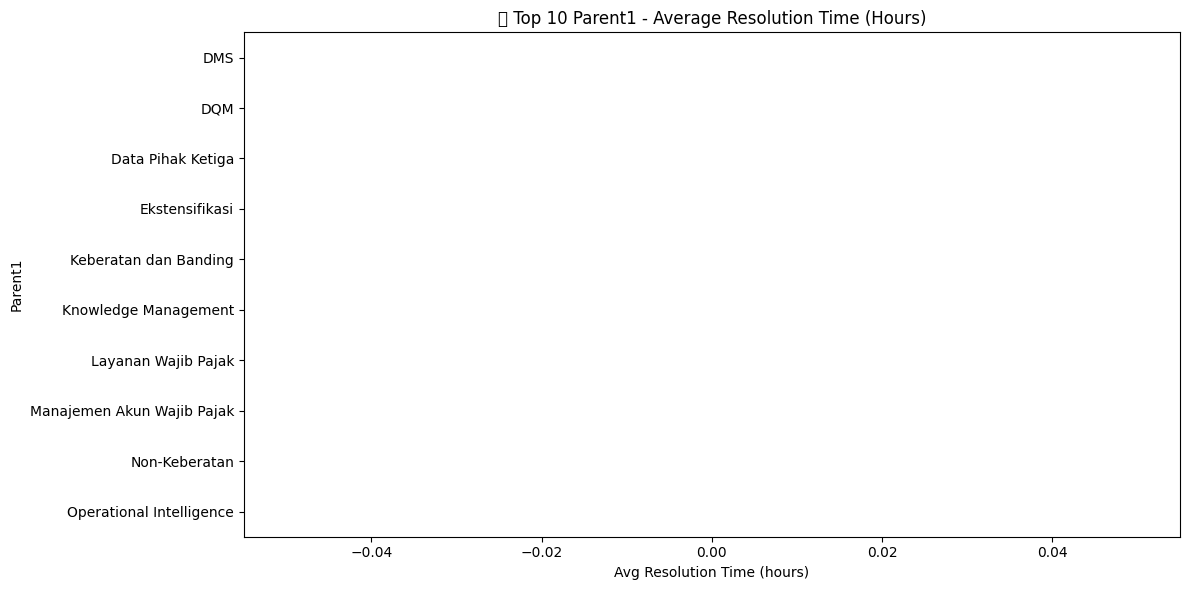

C:\Users\PSIAP\my_env\Lib\site-packages\seaborn\matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
C:\Users\PSIAP\my_env\Lib\site-packages\seaborn\matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
C:\Users\PSIAP\AppData\Local\Temp\ipykernel_9848\2902249770.py:71: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PSIAP\my_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 9201 (\N{STOPWATCH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


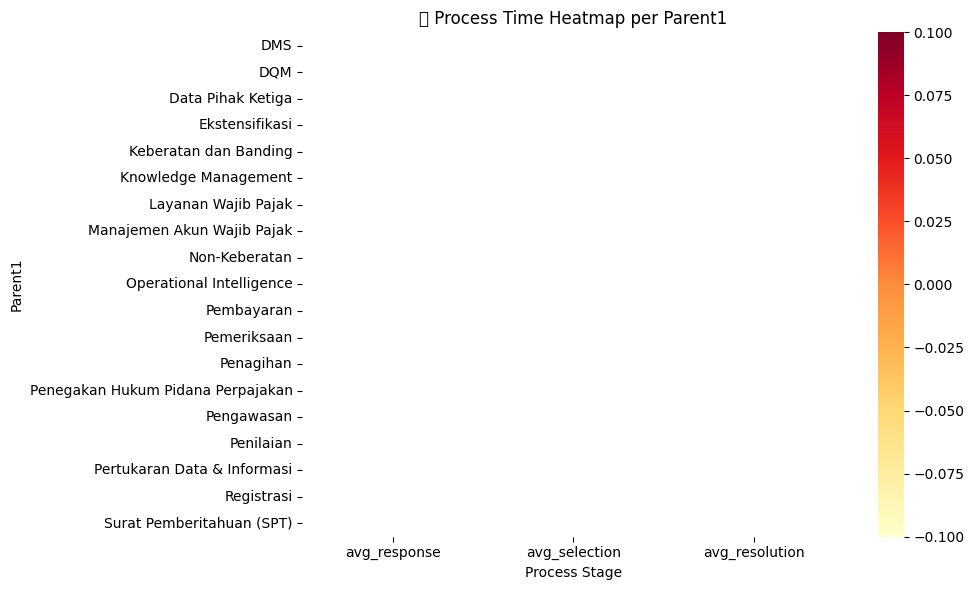

C:\Users\PSIAP\AppData\Local\Temp\ipykernel_9848\2902249770.py:78: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(
C:\Users\PSIAP\AppData\Local\Temp\ipykernel_9848\2902249770.py:90: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
C:\Users\PSIAP\AppData\Local\Temp\ipykernel_9848\2902249770.py:91: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\PSIAP\my_env\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


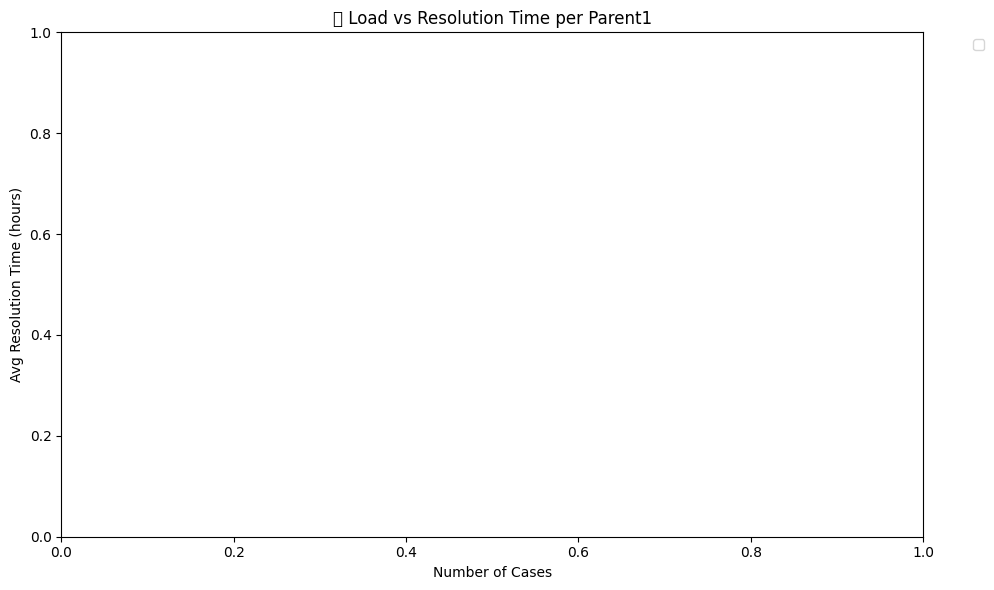

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_file = df.copy()

# 1. Pastikan kolom dasar ada (hindari case sensitive atau spasi)
df.columns = df.columns.str.strip()

# 2. Konversi ke datetime
for col in ["question_date", "answered_date", "selected_date"]:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")
    else:
        # Jika kolom sumber tidak ada, buat kolom kosong agar tidak error nanti
        df[col] = pd.NaT

# 3. Hitung selisih waktu (pasti aman karena kolom sudah dijamin ada)
df["response_time_h"] = (df["answered_date"] - df["question_date"]).dt.total_seconds() / 3600
df["selection_time_h"] = (df["selected_date"] - df["answered_date"]).dt.total_seconds() / 3600
df["resolution_time_h"] = (df["selected_date"] - df["question_date"]).dt.total_seconds() / 3600

# 4. Agregasi
# Pastikan 'parent1' memang ada di df.columns
if "parent1" in df.columns:
    parent_summary = df.groupby("parent1").agg(
        avg_response=("response_time_h", "mean"),
        avg_selection=("selection_time_h", "mean"),
        avg_resolution=("resolution_time_h", "mean"),
        count=("parent1", "count")
    ).reset_index()
    
    parent_summary = parent_summary.sort_values("avg_resolution", ascending=False)
else:
    print("Error: Kolom 'parent1' tidak ditemukan!")

# =========================
# 1. BAR CHART: AVG RESOLUTION TIME
# =========================
plt.figure(figsize=(12,6))
sns.barplot(
    data=parent_summary.head(10),
    x="avg_resolution",
    y="parent1",
    palette="Reds_r"
)
plt.title("🔥 Top 10 Parent1 - Average Resolution Time (Hours)")
plt.xlabel("Avg Resolution Time (hours)")
plt.ylabel("Parent1")
plt.tight_layout()
plt.show()

# =========================
# 2. HEATMAP PROCESS STAGES
# =========================
heatmap_data = parent_summary.set_index("parent1")[[
    "avg_response", "avg_selection", "avg_resolution"
]]

plt.figure(figsize=(10,6))
sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd"
)
plt.title("⏱️ Process Time Heatmap per Parent1")
plt.xlabel("Process Stage")
plt.ylabel("Parent1")
plt.tight_layout()
plt.show()

# =========================
# 3. DISTRIBUTION SCATTER (LOAD vs TIME)
# =========================
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=parent_summary,
    x="count",
    y="avg_resolution",
    size="count",
    hue="avg_resolution",
    palette="coolwarm",
    sizes=(50, 500)
)
plt.title("📦 Load vs Resolution Time per Parent1")
plt.xlabel("Number of Cases")
plt.ylabel("Avg Resolution Time (hours)")
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.tight_layout()
plt.show()

In [53]:
print(df[["question_date", "answered_date", "selected_date"]].head())
print("Jumlah data kosong di response_time_h:", df["response_time_h"].isna().sum())

        question_date answered_date selected_date
0 2026-01-19 04:43:22           NaT           NaT
1 2026-01-05 02:58:47           NaT           NaT
2 2026-04-07 01:49:01           NaT           NaT
3 2026-01-02 08:50:53           NaT           NaT
4 2026-01-09 14:29:34           NaT           NaT
Jumlah data kosong di response_time_h: 1652
